# GSE301280 (Dataset 05) — load & QC skin Xenium SpatialData

GEO human skin Xenium data ([GSE301280](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE301280)).

Loads `sdata.zarr`, checks that `.X` holds raw integer counts, and plots centroids, cell segmentation, and transcripts in a cropped ROI.

**Kernel:** `spatialdata`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor

RAW_DIR = Path("/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_05/raw_data")
DATA_DIR = RAW_DIR.parent.parent
sys.path.insert(0, str(DATA_DIR))
from spatial_plot import (
    attach_morphology_mip,
    build_plot_crop,
    plot_gene_seg_transcripts,
    transcript_roi_center,
)

MIP_PATH = RAW_DIR / "xenium_bundle" / "morphology_mip.ome.tif"

SDATA_PATH = RAW_DIR / "sdata.zarr"

assert SDATA_PATH.is_dir(), f"Missing zarr store: {SDATA_PATH}"
print(f"Zarr path: {SDATA_PATH}")

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Zarr path: /mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_05/raw_data/sdata.zarr


In [2]:
sdata = sd.read_zarr(SDATA_PATH)
adata = sdata["table"]

print("Tables:", list(sdata.tables.keys()))
print("Shapes:", list(sdata.shapes.keys()))
print("Points:", list(sdata.points.keys()))
print("Images:", list(sdata.images.keys()) or "(none)")
print(f"\nAnnData: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f"obs columns ({len(adata.obs.columns)}): {list(adata.obs.columns)}")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"layers: {list(adata.layers.keys()) or '(none)'}")

Tables: ['table']
Shapes: ['cell_boundaries', 'cell_circles']
Points: ['transcripts']
Images: (none)

AnnData: 9,960 cells x 100 genes
obs columns (10): ['cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region']
obsm keys: ['spatial']
layers: (none)


In [3]:
adata.var

,gene_ids,feature_types,genome
ACACA,ENSG00000278540,Gene Expression,Unknown
AHR,ENSG00000106546,Gene Expression,Unknown
AKT1,ENSG00000142208,Gene Expression,Unknown
AR,ENSG00000169083,Gene Expression,Unknown
AREG,ENSG00000109321,Gene Expression,Unknown
...,...,...,...
TP63,ENSG00000073282,Gene Expression,Unknown
TSLP,ENSG00000145777,Gene Expression,Unknown
VDR,ENSG00000111424,Gene Expression,Unknown
VIM,ENSG00000026025,Gene Expression,Unknown


In [4]:
# Attach morphology MIP (not stored in zarr due to image write limits)
if attach_morphology_mip(sdata, MIP_PATH):
    print(f"Attached morphology_mip from {MIP_PATH.name}")
else:
    print("morphology_mip already in SpatialData")

print(f"Table region: {adata.uns['spatialdata_attrs']['region']}")

Attached morphology_mip from morphology_mip.ome.tif
Table region: cell_circles


In [5]:
# Sanity check: .X should hold integer raw transcript counts (GEX panel)
x = adata.X
vals = x.data if hasattr(x, "data") else np.asarray(x).ravel()

assert vals.min() >= 0, f"Expected nonnegative counts, got min={vals.min()}"
assert np.allclose(vals, np.round(vals)), "Non-integer values in .X"

row_sums = np.asarray(x.sum(axis=1)).ravel()
ref_col = "transcript_counts" if "transcript_counts" in adata.obs else "total_counts"
ref = adata.obs[ref_col].to_numpy(dtype=float)
assert np.allclose(row_sums, ref, rtol=1e-4), f"X row sums must match obs['{ref_col}']"

print(f"X holds integer transcript counts (min={vals.min():.0f}, max={vals.max():.0f})")
print(f"Row-sum check vs {ref_col}: OK ({adata.n_obs:,} cells)")

X holds integer transcript counts (min=1, max=141)
Row-sum check vs transcript_counts: OK (9,960 cells)


In [6]:
# Crop ROI centered on dense transcript molecules for the demo gene
GENE_CANDIDATES = ["VIM", "KRT5", "KRT14", "KRT1"]
GENE = next((g for g in GENE_CANDIDATES if g in adata.var_names), adata.var_names[0])
print(f"Demo gene: {GENE}")

coords = adata.obsm["spatial"]
gene_expr = np.asarray(adata[:, GENE].X.todense()).ravel() if hasattr(adata.X, "todense") else np.asarray(adata[:, GENE].X).ravel()
half = 500  # px window half-width
attach_morphology_mip(sdata, MIP_PATH)  # must exist before crop so image is included
cx, cy = transcript_roi_center(sdata, GENE, half=half)
xmin, xmax = cx - half, cx + half
ymin, ymax = cy - half, cy + half

# bbox crop under-counts Xenium transcripts; build_plot_crop re-filters points on x/y
sdata_crop = build_plot_crop(sdata, cx, cy, half, gene=GENE)

mask = (
    (coords[:, 0] >= xmin) & (coords[:, 0] <= xmax) &
    (coords[:, 1] >= ymin) & (coords[:, 1] <= ymax)
)
print(f"ROI center (dense {GENE} transcripts): ({cx:.0f}, {cy:.0f})")
print(f"ROI: x=[{xmin:.0f}, {xmax:.0f}], y=[{ymin:.0f}, {ymax:.0f}]")
print(f"Cells in ROI: {mask.sum():,} / {adata.n_obs:,}")
print(f"{GENE} counts in ROI: {gene_expr[mask].sum():.0f} (mean {gene_expr[mask].mean():.2f} per cell)")
print(f"Shapes in crop: {len(sdata_crop.shapes['cell_boundaries']):,}")
print(f"{GENE} transcript molecules in crop: {len(sdata_crop.points['transcripts']):,}")

Demo gene: VIM


/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


ROI center (dense VIM transcripts): (4771, 3609)
ROI: x=[4271, 5271], y=[3109, 4109]
Cells in ROI: 0 / 9,960
VIM counts in ROI: 0 (mean nan per cell)
Shapes in crop: 304
VIM transcript molecules in crop: 4,596


/tmp/ipykernel_3826861/1002591519.py:24: RuntimeWarning: Mean of empty slice
  print(f"{GENE} counts in ROI: {gene_expr[mask].sum():.0f} (mean {gene_expr[mask].mean():.2f} per cell)")
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


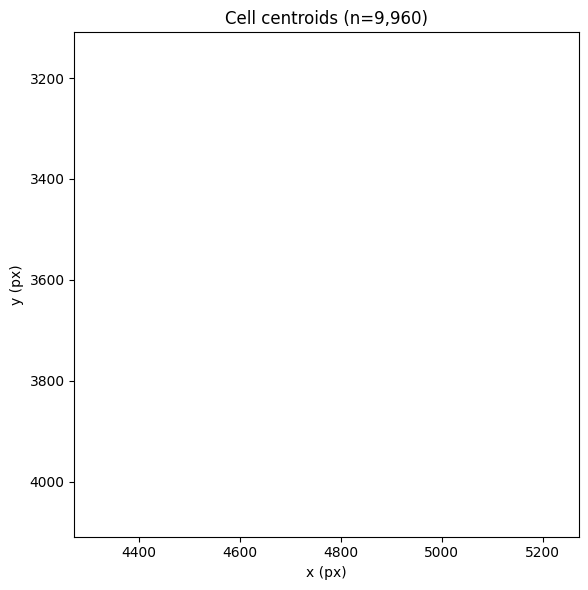

In [7]:
# Plot 1: cell centroids
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(coords[:, 0], coords[:, 1], s=0.3, alpha=0.4, rasterized=True)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymax, ymin)  # image coordinates
ax.set_aspect("equal")
ax.set_xlabel("x (px)")
ax.set_ylabel("y (px)")
ax.set_title(f"Cell centroids (n={adata.n_obs:,})")
plt.tight_layout()
plt.show()

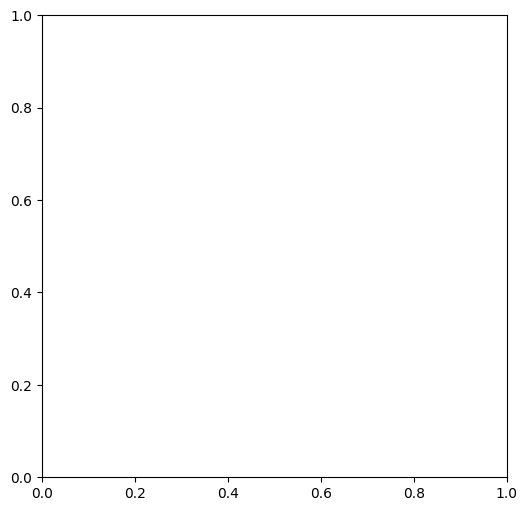

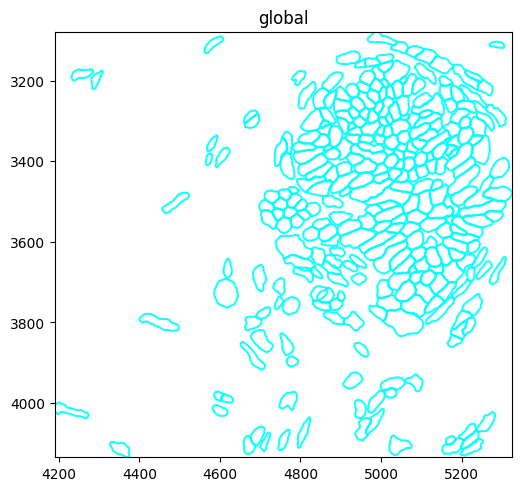

In [8]:
# Plot 2: cell segmentation (boundaries)
fig, ax = plt.subplots(figsize=(6, 6))
(
    sdata_crop.pl
    .render_shapes(
        "cell_boundaries",
        ax=ax,
        outline_color="cyan",
        outline_alpha=0.9,
        fill_alpha=0.0,
    )
    .pl.show(coordinate_systems="global")
)

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1019: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(


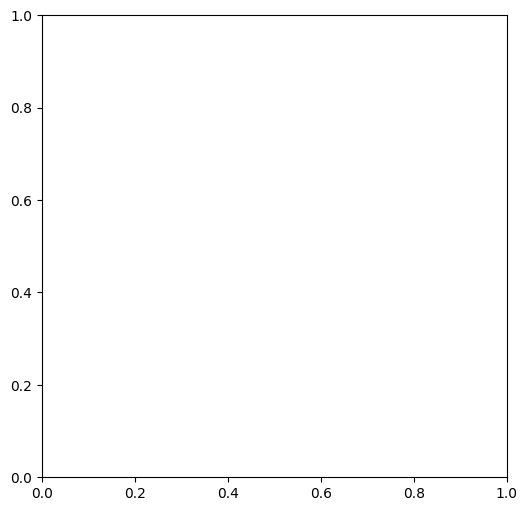

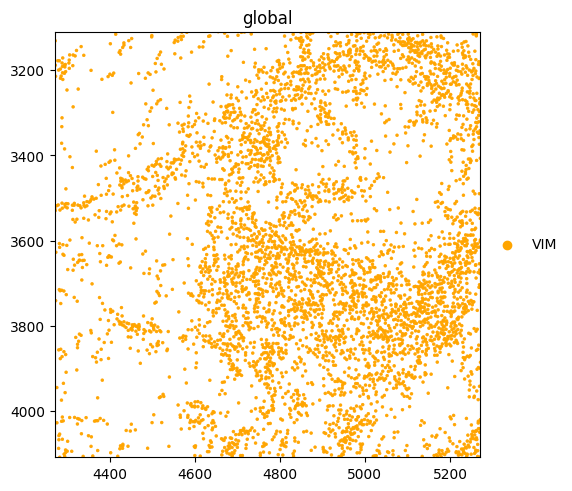

In [9]:
# Plot 3: transcripts for demo gene (spatialdata-plot: color column + groups)
fig, ax = plt.subplots(figsize=(6, 6))
(
    sdata_crop.pl
    .render_points(
        "transcripts",
        color="feature_name",
        groups=GENE,
        palette="orange",
        ax=ax,
        alpha=0.7,
        size=2,
    )
    .pl.show(coordinate_systems="global")
)

Most abundant transcript: VIM (156,790 molecules)


/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1019: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(


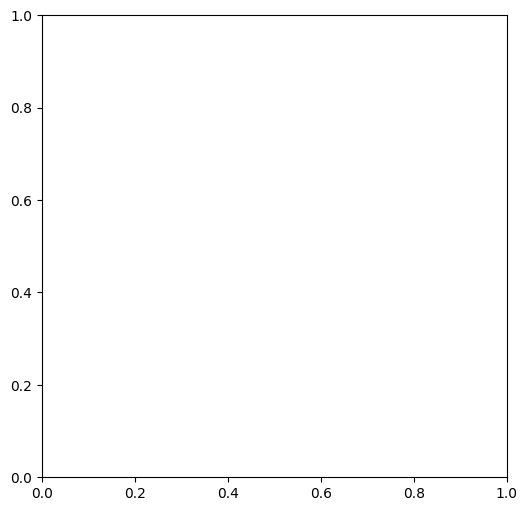

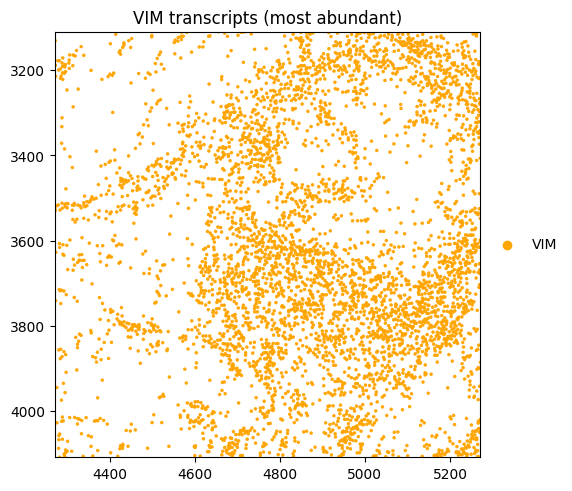

In [10]:
# Most abundant transcript molecule in the dataset
tx_counts = (
    sdata["transcripts"]["feature_name"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
)
TOP_TX = tx_counts.index[0]
print(f"Most abundant transcript: {TOP_TX} ({tx_counts.iloc[0]:,} molecules)")

fig, ax = plt.subplots(figsize=(6, 6))
(
    sdata_crop.pl
    .render_points(
        "transcripts",
        color="feature_name",
        groups=TOP_TX,
        palette="orange",
        ax=ax,
        alpha=0.7,
        size=2,
    )
    .pl.show(
        coordinate_systems="global",
        title=f"{TOP_TX} transcripts (most abundant)",
    )
)

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1019: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(


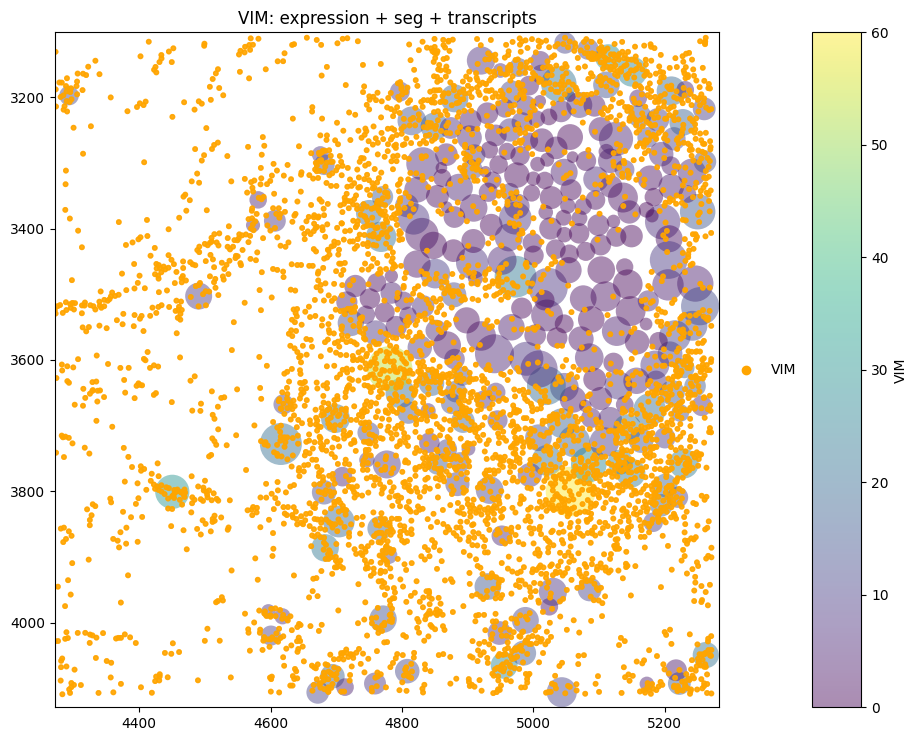

In [11]:
# Modal-agnostic overlay (same function as CosMx; uses table-annotated cell_circles here)
plot_gene_seg_transcripts(sdata_crop, GENE, point_size=10, point_alpha=0.7)

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1019: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(


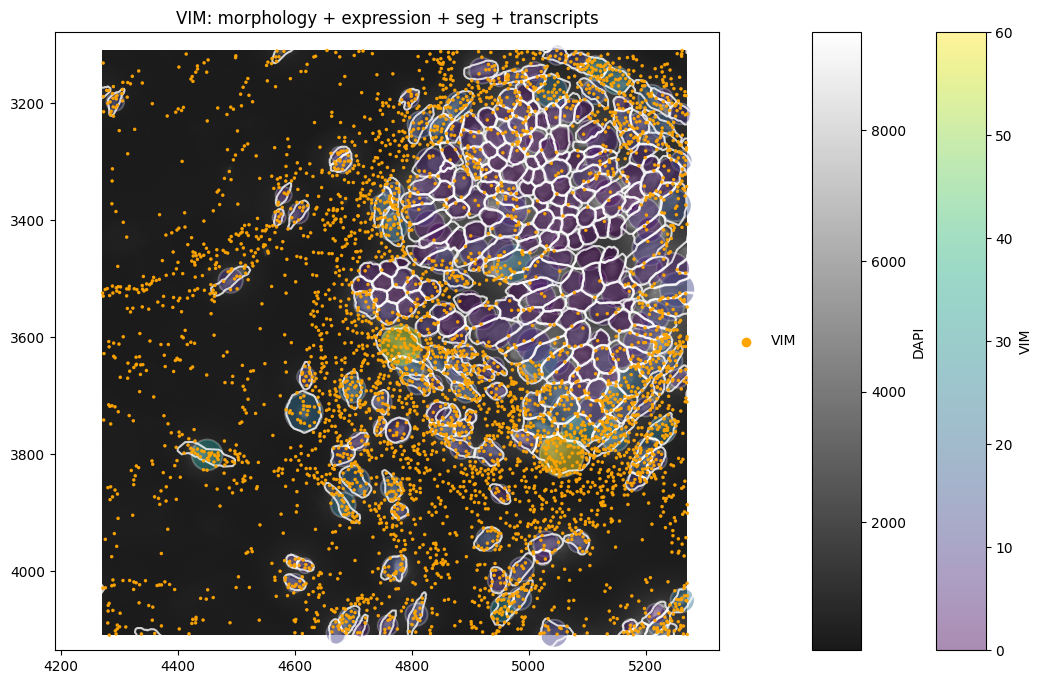

In [12]:
# Combined: morphology + gene expression + cell segmentation + transcripts
if "morphology_mip" not in sdata_crop.images:
    attach_morphology_mip(sdata, MIP_PATH)
    sdata_crop = build_plot_crop(sdata, cx, cy, half, gene=GENE)

(
    sdata_crop.pl
    .render_images("morphology_mip", channel="DAPI", cmap="gray", alpha=0.9)
    .pl.render_shapes(
        "cell_circles",
        color=GENE,
        fill_alpha=0.45,
        outline_alpha=0.3,
        outline_color="white",
    )
    .pl.render_shapes(
        "cell_boundaries",
        outline_color="white",
        fill_alpha=0.0,
        outline_alpha=0.8,
    )
    .pl.render_points(
        "transcripts",
        color="feature_name",
        groups=GENE,
        palette="orange",
        size=2,
        alpha=0.7,
    )
    .pl.show(
        coordinate_systems="global",
        figsize=(8, 8),
        title=f"{GENE}: morphology + expression + seg + transcripts",
    )
)